In [44]:
import sys
import pandas as pd

# 2. FIX PATH TO PROJECT ROOT
sys.path.append('../../')

In [45]:
poc = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/PoC/PoC_results.csv')
static = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/human_review_random_50.csv')
dynamic = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/RAG/dynamic_tagging_results.csv')
human1 = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/humanTagged_Vibe.csv', encoding='latin-1', skiprows=4,)
human2 = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/humanTagged_Christine.csv', encoding='latin-1', skiprows=4)

### Compare human labeld tickets

In [46]:
human1.head()

,number,text,category,scenarios,comments
0,INC0130953,Support - TV/Video on demand/Streamer or Audio...,"(1c TV, 2c COAX)",3 Performance issues,Can´t see which technology anymore
1,INC0155292,Support - YouSee mail/Issue with Mit YouSee/Ca...,"(1g Self service, 2g Webmail)",3 technical issues,NaN
2,INC0122704,Support - My YouSee/App (Mobile/Tablet)/Missin...,"(1g Self service, 2g YS-play)",3 Missing rights to access,Can´t see if it is Yousee Play or another tv-p...
3,INC0126682,Support - YouSee mail/Issue within webmail / u...,"(1g Self service, 2g Webmail)",3 technical issues,NaN
4,INC0124290,Support - Dawn/With Customer context/Finance/O...,"(1a MV Mobile voice, 2a Main product)",3 Billing/Invoices,Billing-isssue


In [47]:
human1['label'] = human1['category'].astype(str) + ', ' + human1['scenarios'].astype(str)
human1['label'] = human1['label'].str.replace('  ', ' ').str.strip()
human2['label'] = human2['category'].astype(str) + ', ' + human2['scenarios'].astype(str)
human2['label'] = human2['label'].str.replace('  ', ' ').str.strip()

In [48]:
human2.head()

,number,text,category,scenarios,comments,label
0,INC0130953,Support - TV/Video on demand/Streamer or Audio...,"(1g Self service, 2g YS-play)",3 technical issues,NaN,"(1g Self service, 2g YS-play), 3 technical issues"
1,INC0155292,Support - YouSee mail/Issue with Mit YouSee/Ca...,"(1g Self service, 2g Webmail)",3 Login issues,NaN,"(1g Self service, 2g Webmail), 3 Login issues"
2,INC0122704,Support - My YouSee/App (Mobile/Tablet)/Missin...,"(1g Self service, 2g Mit YouSee)",3 Login issues,NaN,"(1g Self service, 2g Mit YouSee), 3 Login issues"
3,INC0126682,Support - YouSee mail/Issue within webmail / u...,"(1g Self service, 2g Webmail)",3 technical issues,NaN,"(1g Self service, 2g Webmail), 3 technical issues"
4,INC0124290,Support - Dawn/With Customer context/Finance/O...,"(1a MV Mobile voice, 2a Main product)",3 Billing/Invoices,NaN,"(1a MV Mobile voice, 2a Main product), 3 Billi..."


In [49]:
# Only on catagory
import pandas as pd
from sklearn.metrics import cohen_kappa_score


df1 = human1
df2 = human2

# Quick fix: If your label column is named 'category' instead of 'label', normalize it
if 'category' in df1.columns: df1 = df1.rename(columns={'category': 'label'})
if 'category' in df2.columns: df2 = df2.rename(columns={'category': 'label'})

# 2. Merge on ticket 'number' to ensure we compare the exact same tickets
# Keeping 'text' from df1 so you have the context for review
merged = pd.merge(
    df1[['number', 'text', 'label']], 
    df2[['number', 'label']], 
    on='number', 
    suffixes=('_human1', '_human2')
)

# 3. Calculate Raw Agreement
exact_matches = (merged['label_human1'] == merged['label_human2'])
agreement_pct = exact_matches.mean() * 100

print(f"📊 INTER-RATER RELIABILITY SUMMARY")
print("-" * 35)
print(f"Total tickets compared: {len(merged)}")
print(f"Exact Agreement:        {agreement_pct:.1f}% ({exact_matches.sum()}/{len(merged)} tickets)")

# 4. Calculate Cohen's Kappa
# We use fillna just in case someone left a label completely blank
kappa = cohen_kappa_score(
    merged['label_human1'].fillna('BLANK'), 
    merged['label_human2'].fillna('BLANK')
)
print(f"Cohen's Kappa Score:    {kappa:.3f}")
print("-" * 35)

# 5. Isolate and display the disagreements
disagreements = merged[~exact_matches].copy()

if len(disagreements) > 0:
    print(f"\n⚠️ Found {len(disagreements)} tickets with conflicting labels:")
    display(disagreements[['number', 'label_human1', 'label_human2', 'text']])
    
    # Optional: Save the conflicts to a CSV so you can sit down and discuss them
    # disagreements.to_csv('data/labeled/human_conflicts_to_review.csv', index=False)
else:
    print("\n✅ Perfect match! Both annotators agreed on every single ticket.")

ValueError: Can only compare identically-labeled (both index and columns) DataFrame objects

In [ ]:
# For complete label
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# Create copies so we don't accidentally modify your original dataframes
df1 = human1.copy()
df2 = human2.copy()

# 1. Construct the COMPLETE label for both annotators: "(category), scenario"
if 'category' in df1.columns and 'scenario' in df1.columns:
    df1['label'] = '(' + df1['category'].astype(str) + '), ' + df1['scenario'].astype(str)
    df1['label'] = df1['label'].str.replace('  ', ' ').str.strip()

if 'category' in df2.columns and 'scenario' in df2.columns:
    df2['label'] = '(' + df2['category'].astype(str) + '), ' + df2['scenario'].astype(str)
    df2['label'] = df2['label'].str.replace('  ', ' ').str.strip()

# 2. Merge on ticket 'number' to ensure we compare the exact same tickets
# Keeping 'text' from df1 so you have the context for review
merged = pd.merge(
    df1[['number', 'text', 'label']], 
    df2[['number', 'label']], 
    on='number', 
    suffixes=('_human1', '_human2')
)

# 3. Calculate Raw Agreement on the full label
exact_matches = (merged['label_human1'] == merged['label_human2'])
agreement_pct = exact_matches.mean() * 100

print(f"📊 INTER-RATER RELIABILITY SUMMARY (FULL LABEL)")
print("-" * 45)
print(f"Total tickets compared: {len(merged)}")
print(f"Exact Agreement:        {agreement_pct:.1f}% ({exact_matches.sum()}/{len(merged)} tickets)")

# 4. Calculate Cohen's Kappa
# We use fillna just in case someone left a label completely blank
kappa = cohen_kappa_score(
    merged['label_human1'].fillna('BLANK'), 
    merged['label_human2'].fillna('BLANK')
)
print(f"Cohen's Kappa Score:    {kappa:.3f}")
print("-" * 45)

# 5. Isolate and display the disagreements
disagreements = merged[~exact_matches].copy()

if len(disagreements) > 0:
    print(f"\n⚠️ Found {len(disagreements)} tickets with conflicting full labels:")
    display(disagreements[['number', 'label_human1', 'label_human2', 'text']])
    
    # Optional: Save the conflicts to a CSV so you can sit down and discuss them
    # disagreements.to_csv('data/labeled/human_conflicts_to_review.csv', index=False)
else:
    print("\n✅ Perfect match! Both annotators agreed on every single ticket's category AND scenario.")

📊 INTER-RATER RELIABILITY SUMMARY (FULL LABEL)
---------------------------------------------
Total tickets compared: 50
Exact Agreement:        44.0% (22/50 tickets)
Cohen's Kappa Score:    0.413
---------------------------------------------

⚠️ Found 28 tickets with conflicting full labels:


,number,label_human1,label_human2,text
0,INC0130953,"(1c TV, 2c COAX), 3 Performance issues","(1g Self service, 2g YS-play), 3 technical issues",Support - TV/Video on demand/Streamer or Audio...
1,INC0155292,"(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 Login issues",Support - YouSee mail/Issue with Mit YouSee/Ca...
2,INC0122704,"(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g Mit YouSee), 3 Login issues",Support - My YouSee/App (Mobile/Tablet)/Missin...
5,INC0136694,"(1g Self service, 2g Mit YouSee), 3 Quote error","(1a MV Mobile voice, 2a Main product), 3 Login...",Support - Login/Quote (eCommerce)/Other Custom...
6,INC0132053,"(1g Self service, 2g YouSee Music), 3 User error","(1g Self service, 2g YouSee Music), 3 Login is...",Support - Music/Other The Customer has tried t...
7,INC0134277,"(1c TV, 2c COAX), 3 Termination","(1c TV, 2c Fiber), 3 technical issues",Support - TV/Other/Other The Customer cannot g...
8,INC0146510,"(1g Self service, 2g Mit YouSee), 3 Billing/In...","(1g Self service, 2g Mit YouSee), 3 Login issues",Support - My YouSee/Web (PC/Mac)/Missing conte...
12,INC0143436,"(1g Self service, 2g Mit YouSee), 3 Billing/In...","(1g Self service, 2g Mit YouSee), 3 Login issues",Support - Issues with Billing/Automatic paymen...
14,INC0140777,"(1g Self service, 2g YouSee Music), 3 Missing ...","(1g Self service, 2g Mit YouSee), 3 technical ...",Support - Music/Content/Other Customer experie...
16,INC0133806,"(1g Self service, 2g Mit YouSee), 3 Missing ri...","(1d Broadband, 2d Fiber), 3 Login issues",Support - Login/My YouSee/Current Dual Stack C...


### Merge dataframes

In [ ]:
# --- Normalize columns and merge all 4 datasets on 'number' ---
def _prepare_frame(df, name):
    required = ['number', 'label']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

    text_col = 'text' if 'text' in df.columns else None
    reasoning_col = 'reasoning' if 'reasoning' in df.columns else None
    conf_col = None
    for candidate in ['scientific_confidence', 'confidence_score']:
        if candidate in df.columns:
            conf_col = candidate
            break

    keep = ['number', 'label']
    if reasoning_col:
        keep.append(reasoning_col)
    if text_col:
        keep.append(text_col)
    if conf_col:
        keep.append(conf_col)

    out = df[keep].copy()
    rename_map = {
        'label': f'label_{name}',
    }
    if reasoning_col:
        rename_map[reasoning_col] = f'reasoning_{name}'
    if text_col:
        rename_map[text_col] = f'text_{name}'
    if conf_col:
        rename_map[conf_col] = f'scientific_confidence_{name}'

    return out.rename(columns=rename_map)

# Rename human columns to match expected schema before prep
human_renamed = human2.rename(columns={'label': 'label'}) # CHANGE HERE TO HUMAN2!!!!!!

static_prepared = _prepare_frame(static, 'static')
dynamic_prepared = _prepare_frame(dynamic, 'dynamic')
poc_prepared = _prepare_frame(poc, 'poc')
human_prepared = _prepare_frame(human_renamed, 'human')

merged = (
    static_prepared
    .merge(dynamic_prepared, on='number', how='inner')
    .merge(poc_prepared, on='number', how='inner')
    .merge(human_prepared, on='number', how='inner')
)

# Keep one canonical text column
text_candidates = [c for c in ['text_poc', 'text_static', 'text_dynamic', 'text_human'] if c in merged.columns]
if text_candidates:
    merged['text'] = merged[text_candidates].bfill(axis=1).iloc[:, 0]

# Add max_path_confidence from static/dynamic if available
if 'max_path_confidence' in static.columns:
    merged = merged.merge(
        static[['number', 'max_path_confidence']].rename(
            columns={'max_path_confidence': 'max_path_confidence_static'}
        ),
        on='number',
        how='left',
    )
if 'max_path_confidencence' in dynamic.columns:
    merged = merged.merge(
        dynamic[['number', 'max_path_confidencence']].rename(
            columns={'max_path_confidencence': 'max_path_confidence_dynamic'}
        ),
        on='number',
        how='left',
    )


# Drop duplicate text columns and enforce requested order
drop_text_cols = [c for c in ['text_poc', 'text_static', 'text_dynamic', 'text_human'] if c in merged.columns]
if drop_text_cols:
    merged = merged.drop(columns=drop_text_cols)

ordered_cols = [
    'number',
    'text',
    'label_human', 'label_poc', 'label_static', 'label_dynamic',
    'reasoning_human', 'reasoning_poc', 'reasoning_static', 'reasoning_dynamic',
    'scientific_confidence_poc', 'scientific_confidence_static', 'scientific_confidence_dynamic',
    'max_path_confidence_static', 'max_path_confidence_dynamic',
]

# Keep only columns that exist, then append any extras
ordered_existing = [c for c in ordered_cols if c in merged.columns]
remaining_cols = [c for c in merged.columns if c not in ordered_existing]
merged = merged[ordered_existing + remaining_cols]

print(f"Merged shape: {merged.shape}")
merged.head()

Merged shape: (50, 14)


,number,text,label_human,label_poc,label_static,label_dynamic,reasoning_poc,reasoning_static,reasoning_dynamic,scientific_confidence_poc,scientific_confidence_static,scientific_confidence_dynamic,max_path_confidence_static,max_path_confidence_dynamic
0,INC0130953,Support - TV/Video on demand/Streamer or Audio...,"(1c TV, 2c COAX), 3 Performance issues","(1g Self service, 2g YS-play), 3 Performance i...","(1c TV, 2c OTT), 3 Performance issues","(1c TV, 2c OTT), 3 Performance issues",The issue concerns YouSee Play streaming where...,"(1c TV, 2c OTT), 3 Performance issues\nReasoni...",The issue is lagging on a YouSee Play streamer...,0.84,0.8195,0.9814,0.90,0.96
1,INC0155292,Support - YouSee mail/Issue with Mit YouSee/Ca...,"(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 Login issues","(1g Self service, 2g Webmail), 3 Login issues","(1g Self service, 2g Webmail), 3 Login issues",The customer’s YouSee mail account is locked (...,"Tag: (1g Self service, 2g Webmail), 3 Login is...",Customer’s YouSee email is locked in Sentry an...,0.88,0.9700,1.0000,0.90,1.00
2,INC0122704,Support - My YouSee/App (Mobile/Tablet)/Missin...,"(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...",The customer can log in to YouSee Play but is ...,"(1g Self service, 2g YS-play), 3 Missing right...",The issue is with YouSee Play access rights (e...,0.88,0.8172,0.9922,0.86,0.99
3,INC0126682,Support - YouSee mail/Issue within webmail / u...,"(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical issues",The issue is with YouSee Webmail functionality...,"Tag: (1g Self service, 2g Webmail), 3 technica...",The issue is with YouSee Webmail functionality...,0.87,0.9688,1.0000,0.92,1.00
4,INC0124290,Support - Dawn/With Customer context/Finance/O...,"(1a MV Mobile voice, 2a Main product), 3 Billi...","(1a MV Mobile voice, 2a Main product), 3 Billi...","(1a MV Mobile voice, 2a Main product), 3 Billi...","(1a MV Mobile voice, 2a Main product), 3 Billi...",The issue is a dispute over charges for intern...,"Tag: (1a MV Mobile voice, 2a Main product), 3 ...",Disputed charges for international SMS on spec...,0.90,0.9634,0.9982,0.90,1.00


## EDA – Static vs Dynamic Comparison

Label Agreement Summary (%)
Static vs Dynamic    72.0
Static vs PoC        90.0
Dynamic vs PoC       66.0
All 3 Agree          66.0
dtype: float64

All-three label agreement: 33 / 50 (66.0%)



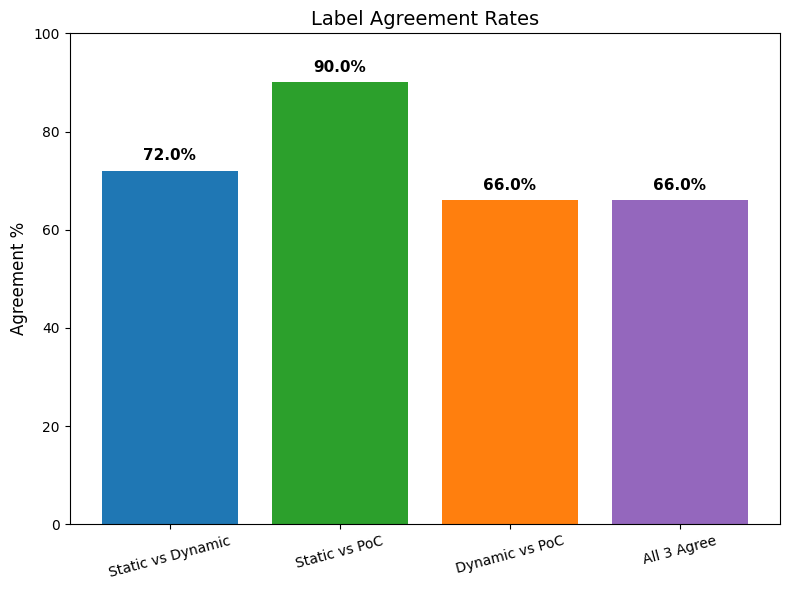

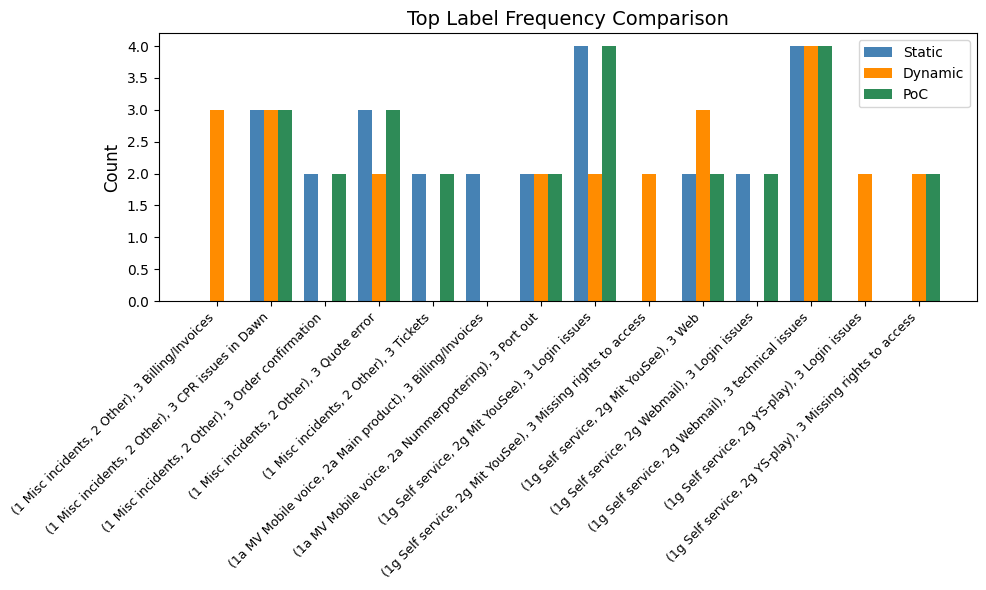

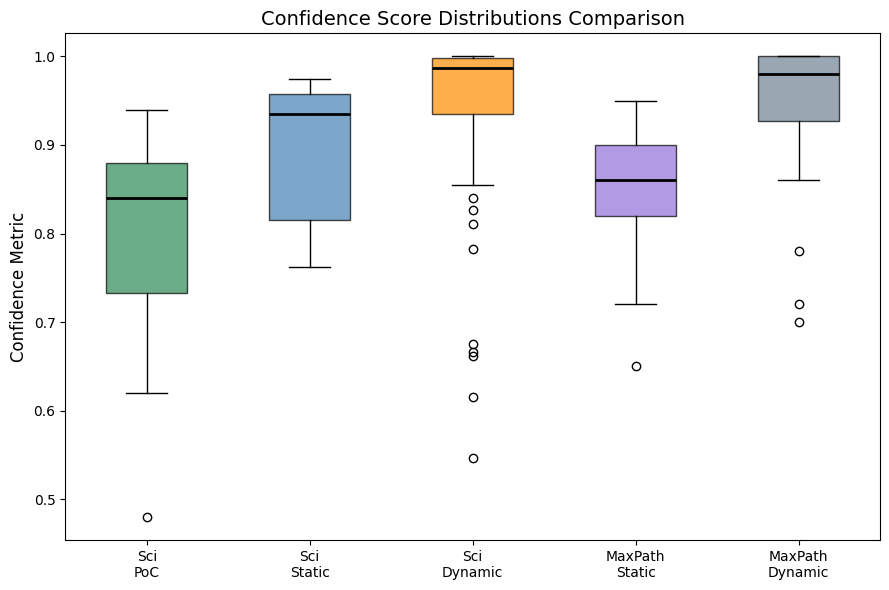

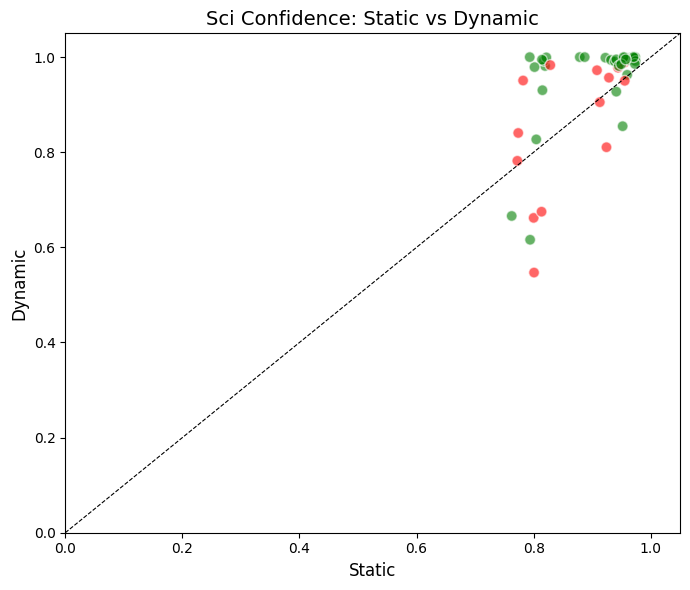

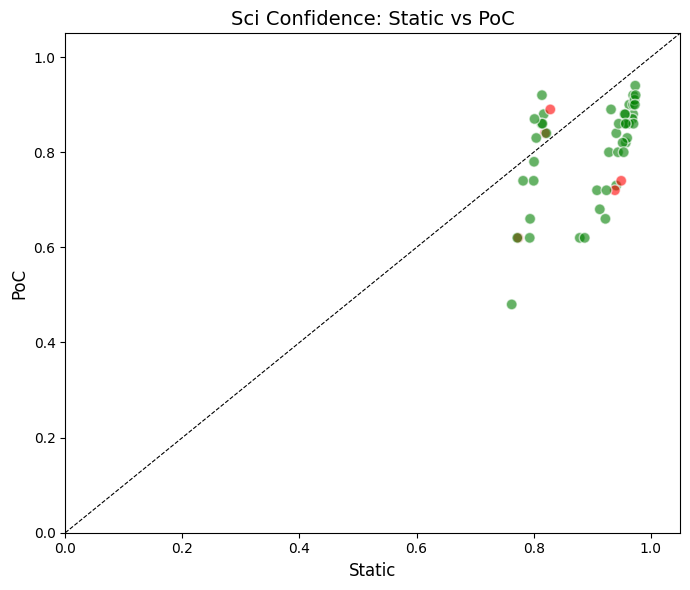

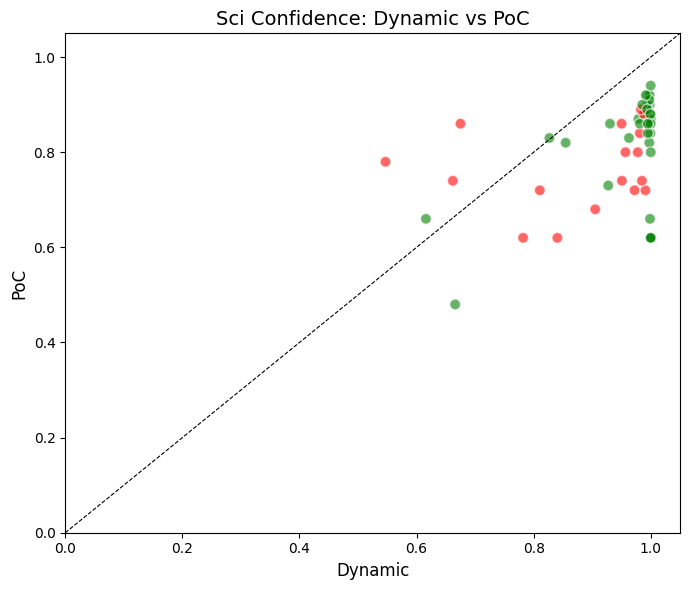

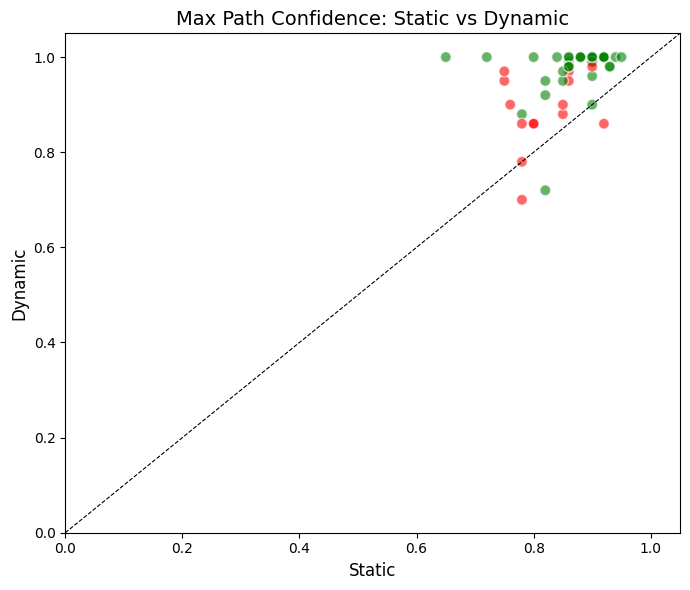

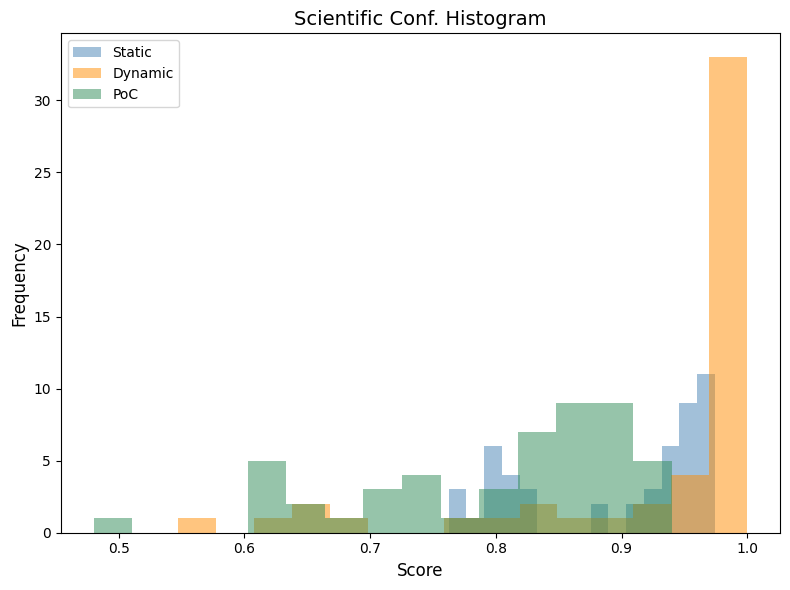

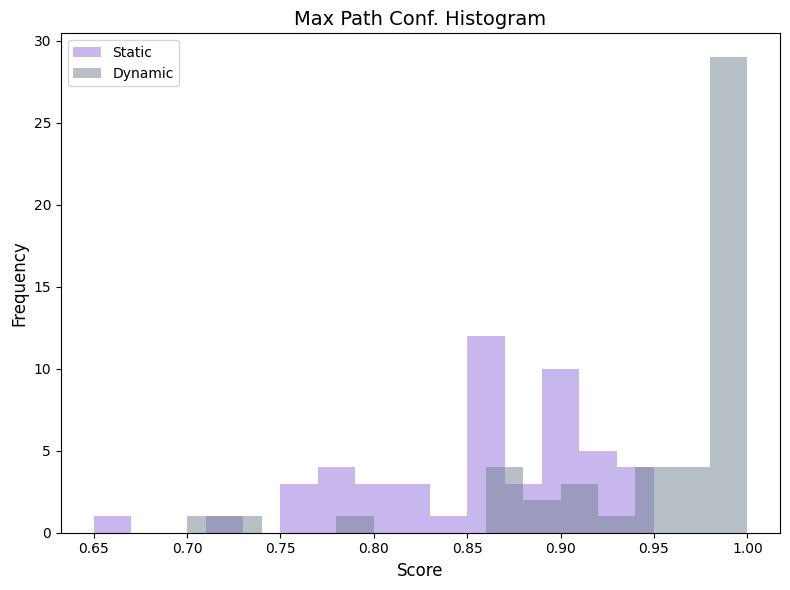

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Label Agreement Metrics
label_agree_sd = (merged['label_static'] == merged['label_dynamic'])
label_agree_sp = (merged['label_static'] == merged['label_poc'])
label_agree_dp = (merged['label_dynamic'] == merged['label_poc'])
label_agree_all3 = label_agree_sd & label_agree_sp

agree_summary = pd.Series({
    'Static vs Dynamic': label_agree_sd.mean() * 100,
    'Static vs PoC': label_agree_sp.mean() * 100,
    'Dynamic vs PoC': label_agree_dp.mean() * 100,
    'All 3 Agree': label_agree_all3.mean() * 100,
})

print('Label Agreement Summary (%)')
print(agree_summary.round(2))
print(f"\nAll-three label agreement: {label_agree_all3.sum()} / {len(merged)} ({agree_summary['All 3 Agree']:.1f}%)\n")

# --- Individual Visualizations ---

# 1.1) Agreement Bar Chart
plt.figure(figsize=(8, 6))
bar_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
bars = plt.bar(agree_summary.index, agree_summary.values, color=bar_colors)
plt.ylim(0, 100)
plt.ylabel('Agreement %', fontsize=12)
plt.title('Label Agreement Rates', fontsize=14)
plt.xticks(rotation=15)
for bar in bars:
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 1.2) Top Label Distribution (All 3)
plt.figure(figsize=(10, 6))
top_n = 10
static_counts = merged['label_static'].value_counts().head(top_n)
dynamic_counts = merged['label_dynamic'].value_counts().head(top_n)
poc_counts = merged['label_poc'].value_counts().head(top_n)
all_labels = static_counts.index.union(dynamic_counts.index).union(poc_counts.index)

x = np.arange(len(all_labels))
w = 0.26
plt.bar(x - w, [static_counts.get(lbl, 0) for lbl in all_labels], w, label='Static', color='steelblue')
plt.bar(x, [dynamic_counts.get(lbl, 0) for lbl in all_labels], w, label='Dynamic', color='darkorange')
plt.bar(x + w, [poc_counts.get(lbl, 0) for lbl in all_labels], w, label='PoC', color='seagreen')
plt.xticks(x, all_labels, rotation=45, ha='right', fontsize=9)
plt.title('Top Label Frequency Comparison', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 1.3) Overall Confidence Boxplots
try:
    plt.figure(figsize=(9, 6))
    box_data = [
        merged['scientific_confidence_poc'].dropna(),
        merged['scientific_confidence_static'].dropna(),
        merged['scientific_confidence_dynamic'].dropna(),
        merged['max_path_confidence_static'].dropna(),
        merged['max_path_confidence_dynamic'].dropna()
    ]
    box_labels = ['Sci\nPoC', 'Sci\nStatic', 'Sci\nDynamic', 'MaxPath\nStatic', 'MaxPath\nDynamic']
    box_colors = ['seagreen', 'steelblue', 'darkorange', 'mediumpurple', 'slategray']

    ax = plt.gca()
    # Handle older matplotlib versions with `labels` fallback to fix the deprecation warning
    try:
        bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='black', linewidth=2), tick_labels=box_labels)
    except TypeError:
        bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='black', linewidth=2), labels=box_labels)
        
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    plt.title('Confidence Score Distributions Comparison', fontsize=14)
    plt.ylabel('Confidence Metric', fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# --- Scientific Confidence Scatter Plots ---
lims = [0, 1.05]

# 2.1) Sci S vs D
plt.figure(figsize=(7, 6))
c_sd = label_agree_sd.map({True: 'green', False: 'red'})
plt.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_dynamic'], c=c_sd, alpha=0.6, edgecolors='white', s=60)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Static vs Dynamic', fontsize=14)
plt.xlabel('Static', fontsize=12); plt.ylabel('Dynamic', fontsize=12)
plt.tight_layout()
plt.show()

# 2.2) Sci S vs P
plt.figure(figsize=(7, 6))
c_sp = label_agree_sp.map({True: 'green', False: 'red'})
plt.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_poc'], c=c_sp, alpha=0.6, edgecolors='white', s=60)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Static vs PoC', fontsize=14)
plt.xlabel('Static', fontsize=12); plt.ylabel('PoC', fontsize=12)
plt.tight_layout()
plt.show()

# 2.3) Sci D vs P
plt.figure(figsize=(7, 6))
c_dp = label_agree_dp.map({True: 'green', False: 'red'})
plt.scatter(merged['scientific_confidence_dynamic'], merged['scientific_confidence_poc'], c=c_dp, alpha=0.6, edgecolors='white', s=60)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Dynamic vs PoC', fontsize=14)
plt.xlabel('Dynamic', fontsize=12); plt.ylabel('PoC', fontsize=12)
plt.tight_layout()
plt.show()

# --- Max Path Confidence Scatter & Histograms ---

# 3.1) Max Path Confidence Scatter: Static vs Dynamic
try:
    plt.figure(figsize=(7, 6))
    plt.scatter(merged['max_path_confidence_static'], merged['max_path_confidence_dynamic'], c=c_sd, alpha=0.6, edgecolors='white', s=60)
    plt.plot(lims, lims, 'k--', lw=0.8)
    plt.xlim(lims); plt.ylim(lims)
    plt.title('Max Path Confidence: Static vs Dynamic', fontsize=14)
    plt.xlabel('Static', fontsize=12); plt.ylabel('Dynamic', fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# 3.2) Histogram: Scientific Confidence Overview
plt.figure(figsize=(8, 6))
plt.hist(merged['scientific_confidence_static'].dropna(), bins=15, alpha=0.5, label='Static', color='steelblue')
plt.hist(merged['scientific_confidence_dynamic'].dropna(), bins=15, alpha=0.5, label='Dynamic', color='darkorange')
plt.hist(merged['scientific_confidence_poc'].dropna(), bins=15, alpha=0.5, label='PoC', color='seagreen')
plt.title('Scientific Conf. Histogram', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 3.3) Histogram: Max Path Confidence
try:
    plt.figure(figsize=(8, 6))
    plt.hist(merged['max_path_confidence_static'].dropna(), bins=15, alpha=0.5, label='Static', color='mediumpurple')
    plt.hist(merged['max_path_confidence_dynamic'].dropna(), bins=15, alpha=0.5, label='Dynamic', color='slategray')
    plt.title('Max Path Conf. Histogram', fontsize=14)
    plt.xlabel('Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")


🎯 Accuracy vs Human Ground Truth (%)
Static Accuracy     42.0
Dynamic Accuracy    42.0
PoC Accuracy        38.0
All 3 Correct       32.0
dtype: float64

All-three correct: 16 / 50 (32.0%)



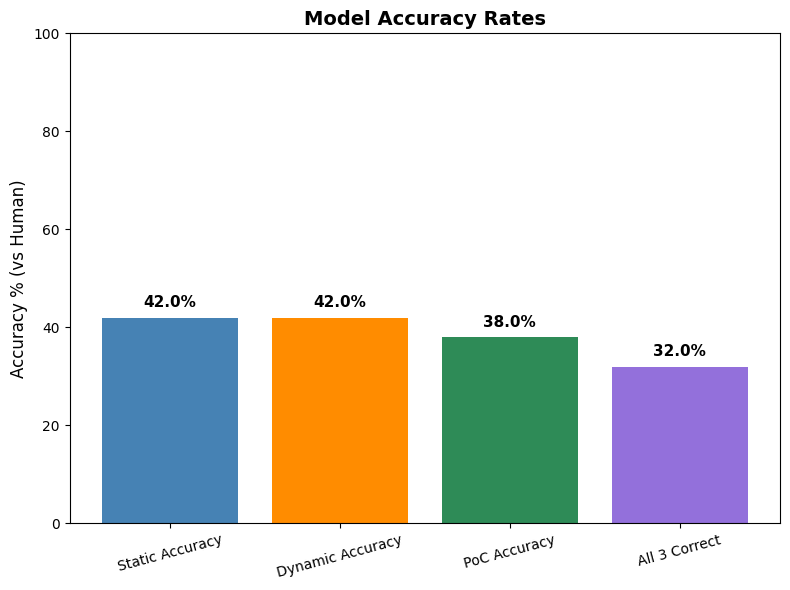

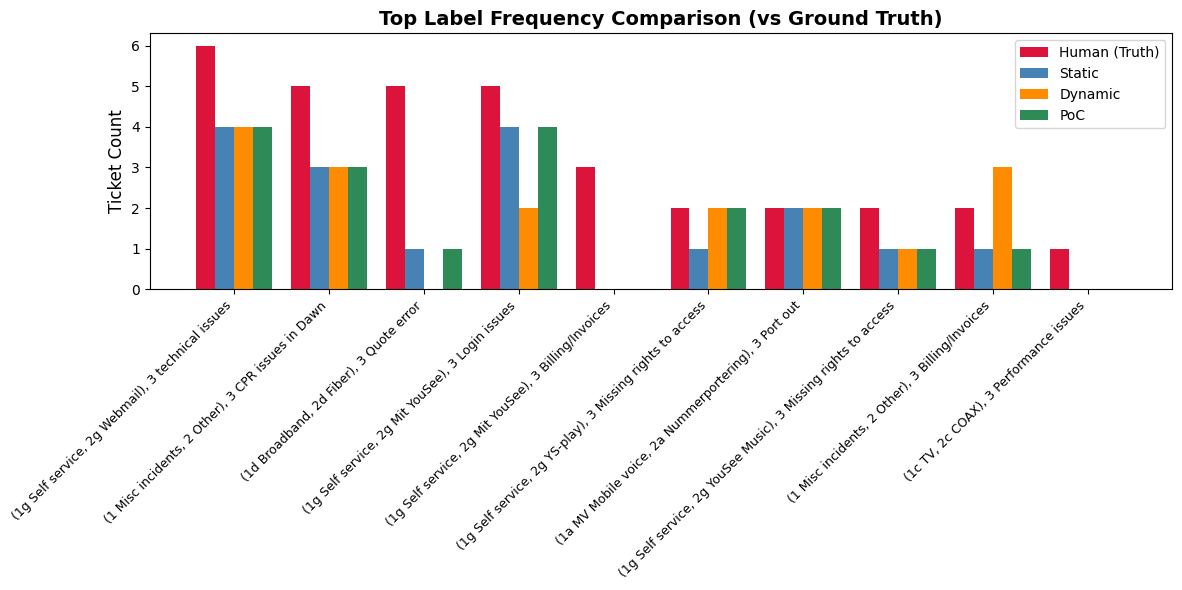

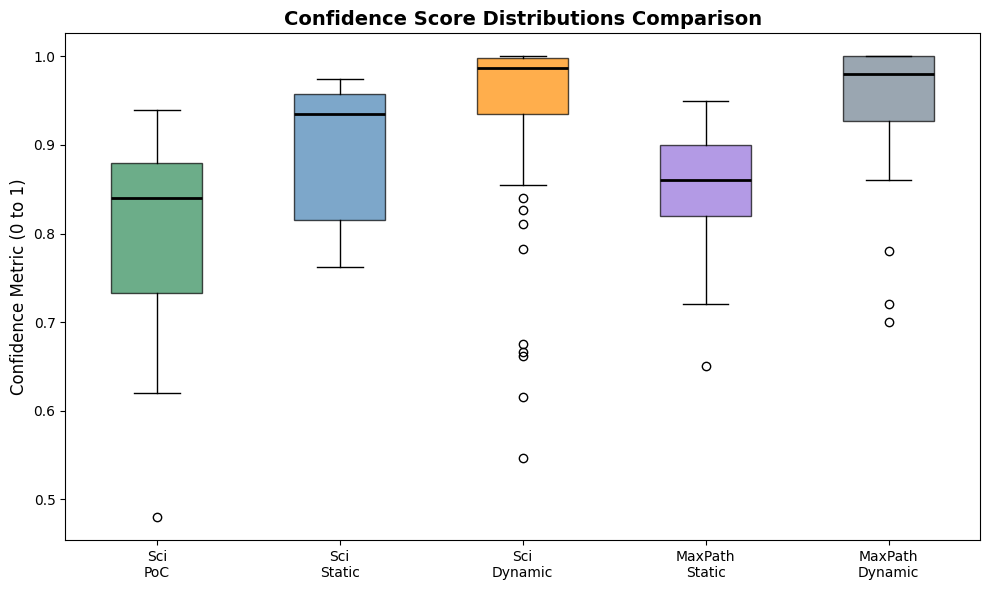

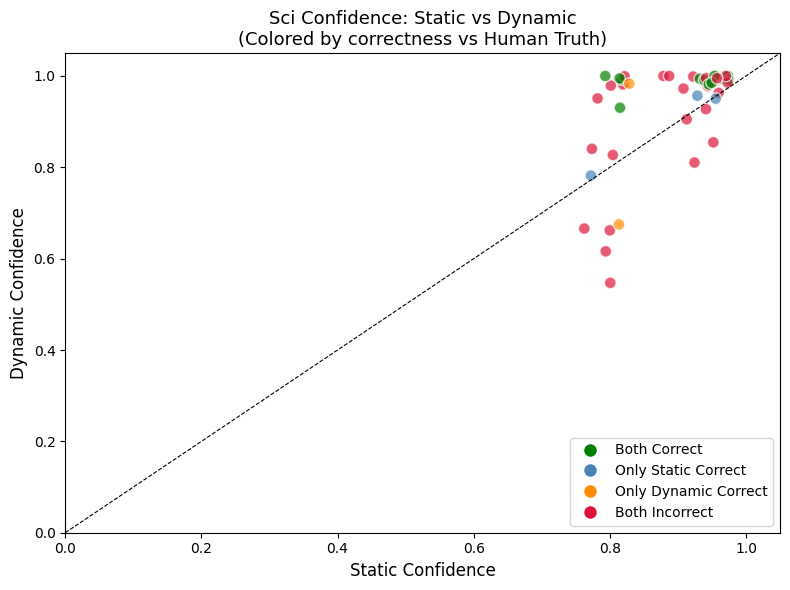

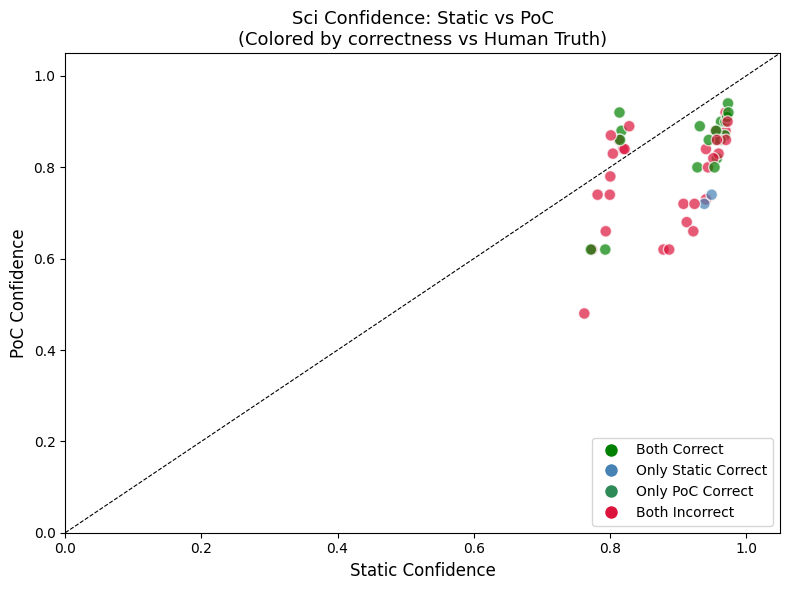

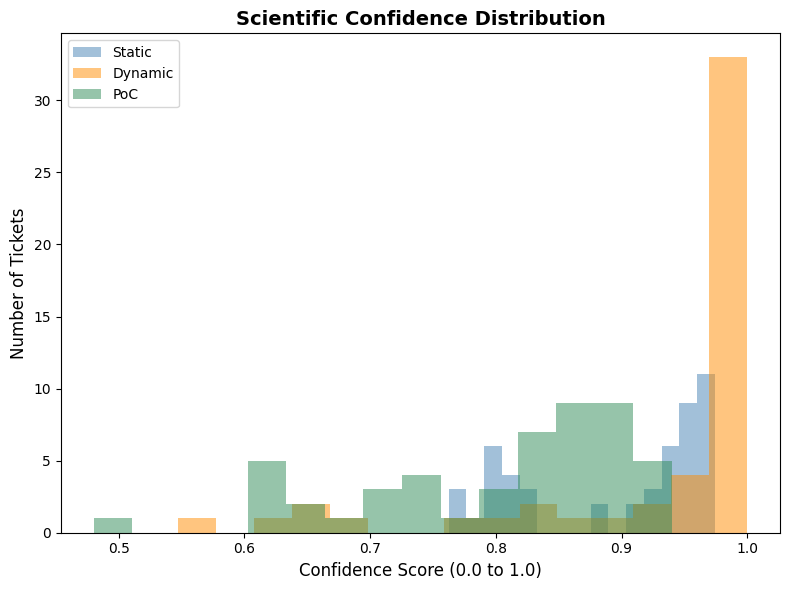

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ==========================================
# 1. ACCURACY METRICS (VS HUMAN GROUND TRUTH)
# ==========================================
acc_static = (merged['label_static'] == merged['label_human'])
acc_dynamic = (merged['label_dynamic'] == merged['label_human'])
acc_poc = (merged['label_poc'] == merged['label_human'])

# Intersection metric: How often were ALL THREE models perfectly correct?
acc_all3 = acc_static & acc_dynamic & acc_poc

acc_summary = pd.Series({
    'Static Accuracy': acc_static.mean() * 100,
    'Dynamic Accuracy': acc_dynamic.mean() * 100,
    'PoC Accuracy': acc_poc.mean() * 100,
    'All 3 Correct': acc_all3.mean() * 100,
})

print('🎯 Accuracy vs Human Ground Truth (%)')
print(acc_summary.round(2))
print(f"\nAll-three correct: {acc_all3.sum()} / {len(merged)} ({acc_summary['All 3 Correct']:.1f}%)\n")


# ==========================================
# 2. OVERALL ACCURACY AND DISTRIBUTION PLOTS
# ==========================================

# 2.1) Accuracy Bar Chart
plt.figure(figsize=(8, 6))
bar_colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
bars = plt.bar(acc_summary.index, acc_summary.values, color=bar_colors)
plt.ylim(0, 100)
plt.ylabel('Accuracy % (vs Human)', fontsize=12)
plt.title('Model Accuracy Rates', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)

for bar in bars:
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 2.2) Top Label Distribution (Now Including Human Truth)
plt.figure(figsize=(12, 6))
top_n = 10

# We use the Human labels as the baseline to see how the models distributed their guesses
human_counts = merged['label_human'].value_counts().head(top_n)
static_counts = merged['label_static'].value_counts()
dynamic_counts = merged['label_dynamic'].value_counts()
poc_counts = merged['label_poc'].value_counts()

all_labels = human_counts.index

x = np.arange(len(all_labels))
w = 0.2

plt.bar(x - 1.5*w, [human_counts.get(lbl, 0) for lbl in all_labels], w, label='Human (Truth)', color='crimson')
plt.bar(x - 0.5*w, [static_counts.get(lbl, 0) for lbl in all_labels], w, label='Static', color='steelblue')
plt.bar(x + 0.5*w, [dynamic_counts.get(lbl, 0) for lbl in all_labels], w, label='Dynamic', color='darkorange')
plt.bar(x + 1.5*w, [poc_counts.get(lbl, 0) for lbl in all_labels], w, label='PoC', color='seagreen')

plt.xticks(x, all_labels, rotation=45, ha='right', fontsize=9)
plt.title('Top Label Frequency Comparison (vs Ground Truth)', fontsize=14, fontweight='bold')
plt.ylabel('Ticket Count', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 3. CONFIDENCE DISTRIBUTIONS
# ==========================================

# 3.1) Overall Confidence Boxplots
try:
    plt.figure(figsize=(10, 6))
    box_data = [
        merged['scientific_confidence_poc'].dropna(),
        merged['scientific_confidence_static'].dropna(),
        merged['scientific_confidence_dynamic'].dropna(),
        merged['max_path_confidence_static'].dropna(),
        merged['max_path_confidence_dynamic'].dropna()
    ]
    box_labels = ['Sci\nPoC', 'Sci\nStatic', 'Sci\nDynamic', 'MaxPath\nStatic', 'MaxPath\nDynamic']
    box_colors = ['seagreen', 'steelblue', 'darkorange', 'mediumpurple', 'slategray']

    ax = plt.gca()
    # Try/except block handles different versions of matplotlib
    try:
        bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='black', linewidth=2), tick_labels=box_labels)
    except TypeError:
        bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='black', linewidth=2), labels=box_labels)
        
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
        
    plt.title('Confidence Score Distributions Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Confidence Metric (0 to 1)', fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Boxplot error: {e}")


# ==========================================
# 4. SCATTER PLOTS: CONFIDENCE VS CORRECTNESS
# ==========================================

# Helper function to color dots based on which model got the correct answer vs Human
def get_scatter_colors(acc_x, acc_y, name_x, name_y):
    colors = []
    for x_correct, y_correct in zip(acc_x, acc_y):
        if x_correct and y_correct: colors.append('green')
        elif x_correct and not y_correct: colors.append('steelblue') # Only X is right
        elif not x_correct and y_correct: colors.append('darkorange') # Only Y is right
        else: colors.append('crimson') # Both are wrong
        
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Both Correct'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label=f'Only {name_x} Correct'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label=f'Only {name_y} Correct'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markersize=10, label='Both Incorrect')
    ]
    return colors, legend_elements

lims = [0, 1.05]

# 4.1) Scientific Confidence: Static vs Dynamic
plt.figure(figsize=(8, 6))
c_sd, leg_sd = get_scatter_colors(acc_static, acc_dynamic, 'Static', 'Dynamic')

plt.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_dynamic'], 
            c=c_sd, alpha=0.7, edgecolors='white', s=70)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Static vs Dynamic\n(Colored by correctness vs Human Truth)', fontsize=13)
plt.xlabel('Static Confidence', fontsize=12); plt.ylabel('Dynamic Confidence', fontsize=12)
plt.legend(handles=leg_sd, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# 4.2) Scientific Confidence: Static vs PoC
plt.figure(figsize=(8, 6))
c_sp, leg_sp = get_scatter_colors(acc_static, acc_poc, 'Static', 'PoC')
# Adjust colors to map PoC to Seagreen for consistency
leg_sp[2].set_markerfacecolor('seagreen') 
c_sp = ['seagreen' if c == 'darkorange' else c for c in c_sp]

plt.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_poc'], 
            c=c_sp, alpha=0.7, edgecolors='white', s=70)
plt.plot(lims, lims, 'k--', lw=0.8)
plt.xlim(lims); plt.ylim(lims)
plt.title('Sci Confidence: Static vs PoC\n(Colored by correctness vs Human Truth)', fontsize=13)
plt.xlabel('Static Confidence', fontsize=12); plt.ylabel('PoC Confidence', fontsize=12)
plt.legend(handles=leg_sp, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


# ==========================================
# 5. HISTOGRAMS
# ==========================================

# 5.1) Histogram: Scientific Confidence Overview
plt.figure(figsize=(8, 6))
plt.hist(merged['scientific_confidence_static'].dropna(), bins=15, alpha=0.5, label='Static', color='steelblue')
plt.hist(merged['scientific_confidence_dynamic'].dropna(), bins=15, alpha=0.5, label='Dynamic', color='darkorange')
plt.hist(merged['scientific_confidence_poc'].dropna(), bins=15, alpha=0.5, label='PoC', color='seagreen')

plt.title('Scientific Confidence Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Score (0.0 to 1.0)', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()